In [19]:
import pandas as pd  # thư viện xử lý dữ liệu bảng
import numpy as np  # mảng số học
from pathlib import Path  # làm việc với đường dẫn file
import matplotlib.pyplot as plt  # vẽ biểu đồ cơ bản
import seaborn as sns  # trực quan hoá dữ liệu
from prophet import Prophet  # model trend time-series
from sklearn.linear_model import LinearRegression, Ridge  # hồi quy tuyến tính và Ridge regularized
from sklearn.tree import DecisionTreeRegressor  # cây hồi quy
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor  # ensemble regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error  # chỉ số đánh giá
%matplotlib inline
# hiển thị chart trong notebook
sns.set(style="whitegrid")  # chọn theme biểu đồ

In [20]:
DATA_DIR = Path('../../processed/clean_data')  # đường dẫn tới dữ liệu sạch
files = sorted(DATA_DIR.glob('clean_2021-*.parquet'))  # tìm các file parquet 2021
print('Number of clean files:', len(files))  # kiểm tra số file
files  # hiển thị danh sách file

Number of clean files: 12


[WindowsPath('../../processed/clean_data/clean_2021-01.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-02.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-03.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-04.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-05.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-06.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-07.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-08.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-09.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-10.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-11.parquet'),
 WindowsPath('../../processed/clean_data/clean_2021-12.parquet')]

In [21]:
columns = ['tpep_pickup_datetime', 'total_amount', 'trip_distance', 'speed_mph']  # chỉ dùng các cột cần thiết
daily_aggregates = []  # chứa kết quả tạm thời cho mỗi file
for path in files:  # lặp qua các file clean data
    print('Loading', path.name)  # in tên file hiện tại
    df = pd.read_parquet(path, columns=columns)  # đọc dữ liệu parquet
    df['pickup_date'] = df['tpep_pickup_datetime'].dt.floor('D')  # chuyển timestamp về ngày
    daily = df.groupby('pickup_date', as_index=False).agg(
        trip_count=('total_amount', 'size'),  # đếm chuyến mỗi ngày
        revenue=('total_amount', 'sum'),  # tổng doanh thu mỗi ngày
        avg_trip_distance=('trip_distance', 'mean'),  # khoảng cách trung bình mỗi chuyến
        avg_speed=('speed_mph', 'mean')  # tốc độ trung bình mỗi ngày
    )
    daily_aggregates.append(daily)  # thêm tổng hợp file hiện tại vào list

daily = pd.concat(daily_aggregates, ignore_index=True)  # ghép dữ liệu các file

daily = daily.groupby('pickup_date', as_index=False).agg(  # hợp nhất theo ngày
    trip_count=('trip_count', 'sum'),  # tổng số chuyến trong ngày
    revenue=('revenue', 'sum'),  # tổng doanh thu trong ngày
    avg_trip_distance=('avg_trip_distance', 'mean'),  # trung bình khoảng cách mỗi ngày
    avg_speed=('avg_speed', 'mean')  # trung bình tốc độ mỗi ngày
)
daily['dow'] = daily['pickup_date'].dt.dayofweek  # ngày trong tuần 0-6
daily['month'] = daily['pickup_date'].dt.month  # tháng trong năm
daily['dayofyear'] = daily['pickup_date'].dt.dayofyear  # thứ tự ngày
daily['is_weekend'] = (daily['dow'] >= 5).astype(int)  # đánh dấu cuối tuần

daily.shape  # kiểm tra kích thước dữ liệu

Loading clean_2021-01.parquet
Loading clean_2021-02.parquet
Loading clean_2021-03.parquet
Loading clean_2021-04.parquet
Loading clean_2021-05.parquet
Loading clean_2021-06.parquet
Loading clean_2021-07.parquet
Loading clean_2021-08.parquet
Loading clean_2021-09.parquet
Loading clean_2021-10.parquet
Loading clean_2021-11.parquet
Loading clean_2021-12.parquet


(365, 9)

In [22]:
daily.head()  # hiển thị vài dòng dữ liệu đã tổng hợp

,pickup_date,trip_count,revenue,avg_trip_distance,avg_speed,dow,month,dayofyear,is_weekend
0,2021-01-01,21851,388904.68,3.340059,16.287716,4,1,1,0
1,2021-01-02,31009,565187.30,3.275843,14.560243,5,1,2,1
2,2021-01-03,23458,457061.59,3.845157,16.765041,6,1,3,1
3,2021-01-04,39006,672348.18,2.938216,13.846943,0,1,4,0
4,2021-01-05,41161,680154.56,2.677505,13.091009,1,1,5,0


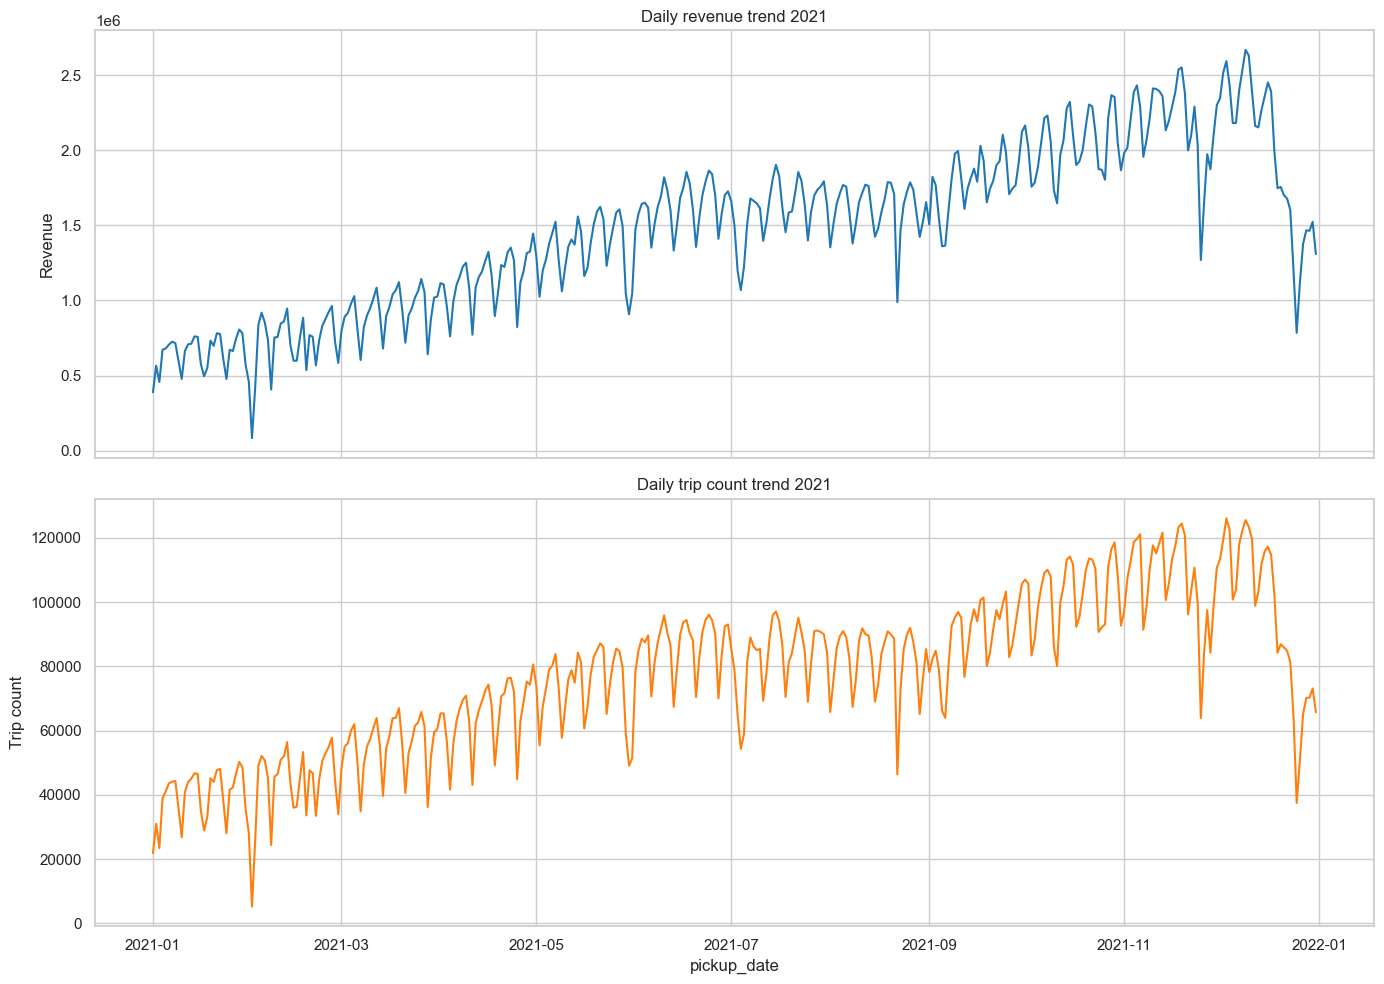

In [23]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(14, 10), sharex=True)  # tạo 2 biểu đồ xếp dọc
sns.lineplot(data=daily, x='pickup_date', y='revenue', ax=axes[0], color='tab:blue')  # doanh thu theo ngày
axes[0].set_title('Daily revenue trend 2021')
axes[0].set_ylabel('Revenue')
sns.lineplot(data=daily, x='pickup_date', y='trip_count', ax=axes[1], color='tab:orange')  # số chuyến theo ngày
axes[1].set_title('Daily trip count trend 2021')
axes[1].set_ylabel('Trip count')
plt.tight_layout()  # căn chỉnh biểu đồ

In [24]:
prophet_df = daily[['pickup_date', 'revenue']].rename(columns={'pickup_date': 'ds', 'revenue': 'y'})  # chuẩn dữ liệu cho Prophet
train_df = prophet_df.iloc[:-60].copy()  # dùng phần lớn dữ liệu cho huấn luyện
test_df = prophet_df.iloc[-60:].copy()  # giữ 60 ngày cuối để đánh giá
model = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)  # khởi tạo Prophet
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)  # thêm mùa hàng tháng
model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)  # thêm mùa hàng quý
model.fit(train_df)  # huấn luyện mô hình
future = model.make_future_dataframe(periods=60)  # tạo khung dữ liệu 60 ngày
forecast = model.predict(future)  # dự báo giá trị doanh thu

11:44:41 - cmdstanpy - INFO - Chain [1] start processing
11:44:41 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
pred_prophet = forecast.set_index('ds').loc[test_df['ds'], 'yhat'].values  # lấy dự báo cho tập test
rmse_prophet = np.sqrt(mean_squared_error(test_df['y'], pred_prophet))  # tính RMSE cho Prophet
mape_prophet = mean_absolute_percentage_error(test_df['y'], pred_prophet)  # tính MAPE cho Prophet
print(f'Prophet RMSE: {rmse_prophet:.2f}')  # in RMSE
print(f'Prophet MAPE: {mape_prophet:.4f}')  # in MAPE

Prophet RMSE: 555303.43
Prophet MAPE: 0.2435


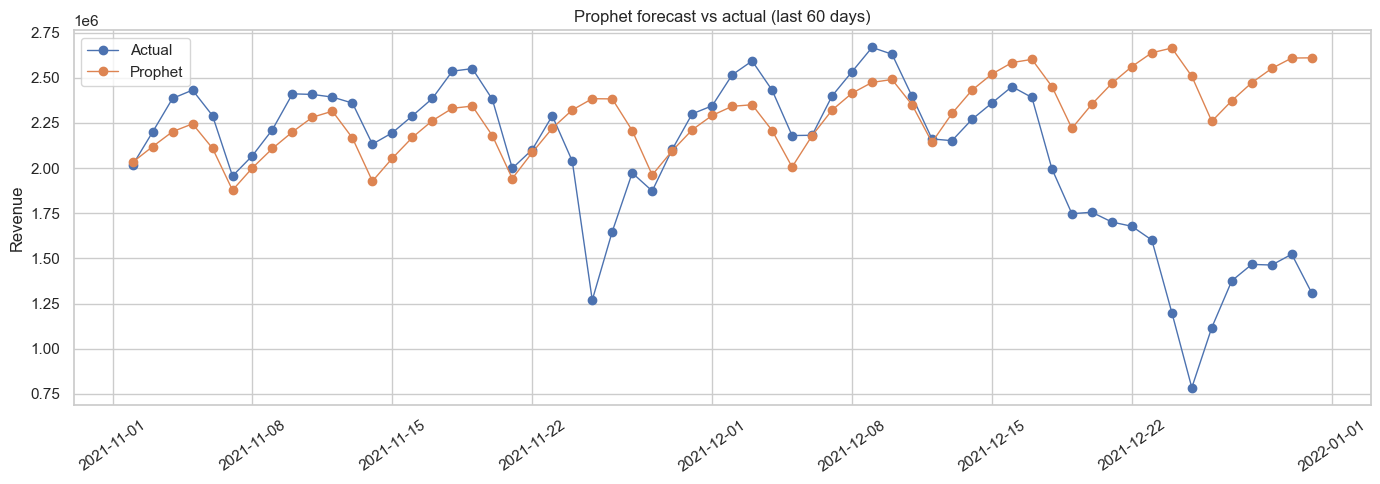

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))  # vẽ so sánh dự báo Prophet và thực tế
ax.plot(test_df['ds'], test_df['y'], label='Actual', marker='o', linewidth=1)  # giá trị thực tế
ax.plot(test_df['ds'], pred_prophet, label='Prophet', marker='o', linewidth=1)  # dự báo Prophet
ax.set_title('Prophet forecast vs actual (last 60 days)')
ax.set_ylabel('Revenue')
ax.legend()  # hiển thị chú giải
plt.xticks(rotation=35)  # xoay nhãn trục x
plt.tight_layout()  # căn chỉnh biểu đồ

In [27]:
features = ['dow', 'month', 'dayofyear', 'is_weekend', 'avg_trip_distance', 'avg_speed']  # đặc trưng đầu vào
X = daily[features]  # ma trận đặc trưng
y = daily['revenue']  # mục tiêu dự báo
X_train, X_test = X.iloc[:-60], X.iloc[-60:]  # chia train/test theo thời gian
y_train, y_test = y.iloc[:-60], y.iloc[-60:]
models = {  # định nghĩa các mô hình so sánh (tuned hyperparameters)
    'LinearRegression': LinearRegression(),  # hồi quy tuyến tính cơ bản
    'Ridge': Ridge(alpha=1.0),  # hồi quy có điều chuẩn
    'DecisionTree': DecisionTreeRegressor(random_state=42, max_depth=8, min_samples_leaf=5),  # giảm overfit
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=12, max_features='sqrt', random_state=42, n_jobs=-1),  # tăng số cây và giới hạn độ sâu
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.03, random_state=42, early_stopping=True)  # boosting với early stopping
}
results = []  # lưu kết quả của mỗi mô hình
for name, clf in models.items():  # lặp huấn luyện và dự báo
    clf.fit(X_train, y_train)  # huấn luyện mô hình
    pred = clf.predict(X_test)  # dự báo trên test set
    pred_train = clf.predict(X_train)  # dự báo trên train để kiểm tra overfit
    rmse = np.sqrt(mean_squared_error(y_test, pred))  # RMSE của mô hình (test)
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))  # RMSE trên train
    mape = mean_absolute_percentage_error(y_test, pred)  # MAPE của mô hình (test)
    print(f'{name} RMSE_train: {rmse_train:.2f}  RMSE_test: {rmse:.2f}  MAPE: {mape:.4f}')  # in kết quả
    results.append((name, pred, rmse, mape, rmse_train))  # lưu kết quả
best_name, best_pred_ml, best_rmse, best_mape, best_rmse_train = min(results, key=lambda x: x[2])  # chọn mô hình tốt nhất theo RMSE
print(f'Best model by RMSE: {best_name} (RMSE_test={best_rmse:.2f}, MAPE={best_mape:.4f}, RMSE_train={best_rmse_train:.2f})')


LinearRegression RMSE: 482331.89    MAPE: 0.2121
DecisionTree RMSE: 394080.06    MAPE: 0.1911
RandomForest RMSE: 375534.21    MAPE: 0.1825
HistGradientBoosting RMSE: 388983.77    MAPE: 0.1890
Best model by RMSE: RandomForest (RMSE=375534.21, MAPE=0.1825)


### Biểu đồ kết quả mô hình

Để đánh giá hiệu năng từng mô hình, mình vẽ 3 loại biểu đồ cho mỗi mô hình (trong tập test 60 ngày):

#### 1. Biểu đồ Actual vs Predicted (Time Series)
- **Trục hoành:** Ngày trong tập test
- **Trục tung:** Doanh thu (VND)
- **Đường xanh (Actual):** Doanh thu thực tế
- **Đường cam (Predicted):** Doanh thu dự báo
- **Ý nghĩa:** Quan sát xu hướng dự báo có sát thực tế hay không; khoảng cách càng nhỏ càng tốt

#### 2. Biểu đồ Scatter (Predicted vs Actual)
- **Trục hoành:** Doanh thu thực tế
- **Trục tung:** Doanh thu dự báo
- **Đường đỏ dashed:** Đường hoàn hảo (y = x)
- **Ý nghĩa:** Các điểm càng gần đường hoàn hảo, dự báo càng chính xác. Nếu điểm nằm trên phía trên/dưới đường: mô hình overestimate/underestimate

#### 3. Biểu đồ Histogram Residuals (Sai số)
- **Trục hoành:** Residuals = Actual - Predicted (sai số)
- **Trục tung:** Tần suất
- **Đường KDE xanh:** Phân bố xác suất của sai số
- **Ý nghĩa:** 
  - Nếu tập trung quanh 0: mô hình unbiased (không lệch)
  - Nếu lệch sang trái/phải: mô hình có xu hướng underestimate/overestimate
  - Hình dạng chuông: sai số tuân theo phân bố chuẩn (tốt)

#### Chỉ tiêu đánh giá
- **RMSE (Root Mean Squared Error):** Lỗi bình phương trung bình - càng nhỏ càng tốt
- **MAPE (Mean Absolute Percentage Error):** Lỗi phần trăm trung bình - chỉ ra % sai lệch trung bình
- So sánh `RMSE_train` vs `RMSE_test`: 
  - Nếu `RMSE_test >> RMSE_train`: mô hình overfitting (giải pháp: regularize)
  - Nếu cả hai lớn: mô hình underfitting (giải pháp: tăng độ phức tạp)


In [ ]:
%matplotlib inline
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
os.makedirs('Data/figures/models', exist_ok=True)
# `results` is a list of tuples (name, pred, rmse, mape, rmse_train) from the models cell
for name, pred, rmse, mape, rmse_train in results:
    fig, axes = plt.subplots(3,1, figsize=(10,12))
    idx = X_test.index
    axes[0].plot(idx, y_test.values, label='actual', marker='o')
    axes[0].plot(idx, pred, label='predicted', marker='x')
    axes[0].set_title(f'{name} - Actual vs Predicted (RMSE={rmse:.0f})')
    axes[0].legend()
    axes[1].scatter(y_test.values, pred, alpha=0.7)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title(f'{name} - Predicted vs Actual')
    resid = y_test.values - pred
    sns.histplot(resid, kde=True, ax=axes[2])
    axes[2].set_title(f'{name} - Residuals histogram (MAPE={mape:.3f})')
    plt.tight_layout()
    # Lưu ảnh
    filename = f'Data/figures/models/{name}_results.png'
    os.makedirs('Data/figures/models', exist_ok=True)
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    print(f'✓ Saved: {filename}')
    plt.close(fig)

    display(fig)
    fname = f'Data/figures/models/{name}_results.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print('Saved', fname)


## HistGradientBoosting riêng với early stopping
Dùng riêng `HistGradientBoostingRegressor` kèm validation set để kiểm tra mô hình này có train đủ tốt mà không overfit hay không.

In [33]:
val_split = 20  # dùng 20 ngày cuối của phần train làm validation cho early stopping
X_train_full = X.iloc[:-60]  # toàn bộ dữ liệu train trước khi test
y_train_full = y.iloc[:-60]  # mục tiêu tương ứng cho train
X_train_bg = X_train_full.iloc[:-val_split]  # dữ liệu huấn luyện chính
y_train_bg = y_train_full.iloc[:-val_split]  # target huấn luyện chính
X_val = X_train_full.iloc[-val_split:]  # validation để dừng sớm
y_val = y_train_full.iloc[-val_split:]  # target validation
histgb_es = HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.05, early_stopping=True, n_iter_no_change=20, random_state=42)
histgb_es.fit(X_train_bg, y_train_bg, X_val=X_val, y_val=y_val)  # huấn luyện với early stopping đúng tham số sklearn
pred_histgb_es = histgb_es.predict(X_test)  # dự báo trên tập test
rmse_histgb_es = np.sqrt(mean_squared_error(y_test, pred_histgb_es))  # RMSE của HistGradientBoosting với early stopping
mape_histgb_es = mean_absolute_percentage_error(y_test, pred_histgb_es)  # MAPE của mô hình này
print(f"HistGradientBoosting early stop RMSE: {rmse_histgb_es:.2f}")
print(f"HistGradientBoosting early stop MAPE: {mape_histgb_es:.4f}")

HistGradientBoosting early stop RMSE: 410118.36
HistGradientBoosting early stop MAPE: 0.2023


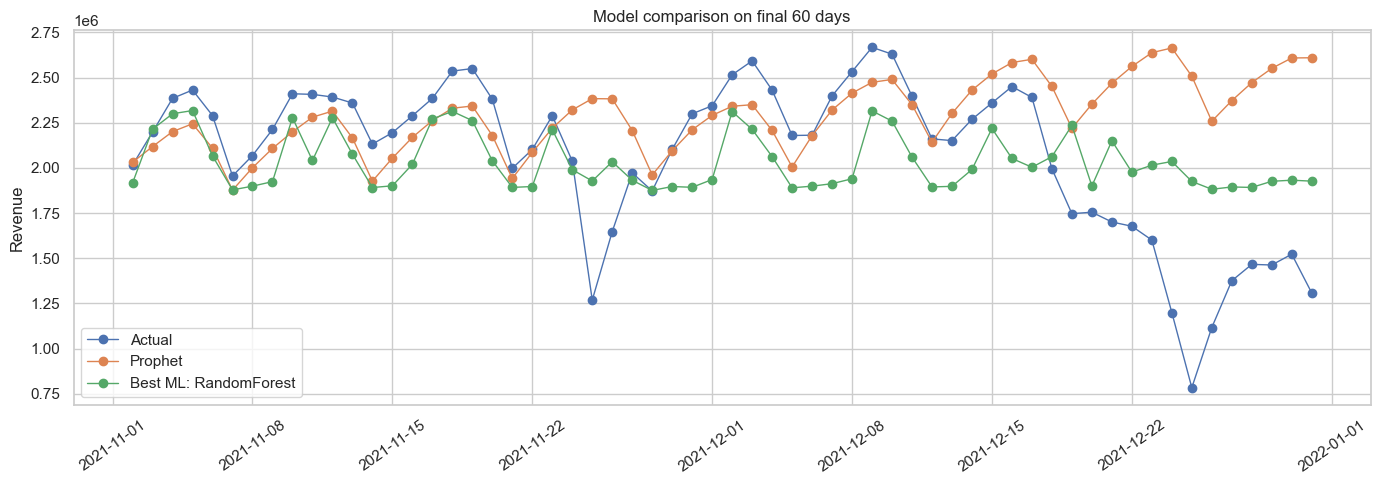

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))  # so sánh Prophet và ML tốt nhất
ax.plot(test_df['ds'], y_test.values, label='Actual', marker='o', linewidth=1)  # thực tế
ax.plot(test_df['ds'], pred_prophet, label='Prophet', marker='o', linewidth=1)  # Prophet
ax.plot(test_df['ds'], best_pred_ml, label=f'Best ML: {best_name}', marker='o', linewidth=1)  # ML tốt nhất
ax.set_title('Model comparison on final 60 days')
ax.set_ylabel('Revenue')
ax.legend()  # hiển thị chú giải
plt.xticks(rotation=35)  # xoay nhãn x
plt.tight_layout()  # căn chỉnh biểu đồ

## Dự báo tương lai bằng Prophet
Prophet là mô hình xu hướng tốt nhất trong notebook này vì nó xử lý tốt xu hướng dài hạn và các tính chất theo tuần/tháng trên dữ liệu ngày.

In [29]:
future_30 = model.make_future_dataframe(periods=30)  # tạo dữ liệu dự báo 30 ngày
forecast_30 = model.predict(future_30)  # dự báo tương lai bằng Prophet
forecast_30[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(15)  # xem 15 dòng cuối dự báo

,ds,yhat,yhat_lower,yhat_upper
320,2021-11-17,2.262285e+06,2.148476e+06,2.383289e+06
321,2021-11-18,2.330777e+06,2.204965e+06,2.452498e+06
322,2021-11-19,2.343123e+06,2.220838e+06,2.462570e+06
323,2021-11-20,2.179585e+06,2.069049e+06,2.295404e+06
324,2021-11-21,1.942017e+06,1.820734e+06,2.062925e+06
325,2021-11-22,2.086288e+06,1.964376e+06,2.204345e+06
326,2021-11-23,2.220379e+06,2.099492e+06,2.339131e+06
327,2021-11-24,2.321433e+06,2.200283e+06,2.440509e+06
328,2021-11-25,2.383890e+06,2.267379e+06,2.510130e+06
329,2021-11-26,2.382827e+06,2.261523e+06,2.503030e+06


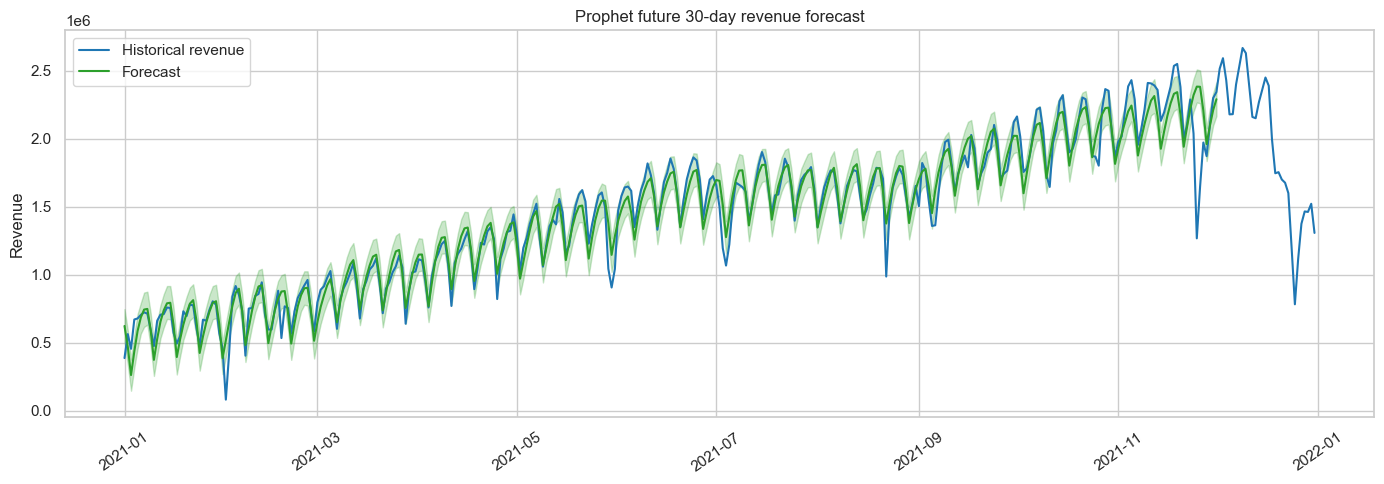

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))  # đồ thị dự báo tương lai
ax.plot(prophet_df['ds'], prophet_df['y'], label='Historical revenue', color='tab:blue')  # dữ liệu lịch sử
ax.plot(forecast_30['ds'], forecast_30['yhat'], label='Forecast', color='tab:green')  # đường dự báo
ax.fill_between(forecast_30['ds'], forecast_30['yhat_lower'], forecast_30['yhat_upper'], color='tab:green', alpha=0.25)  # vùng bất định
ax.set_title('Prophet future 30-day revenue forecast')
ax.set_ylabel('Revenue')
ax.legend()  # hiển thị chú giải
plt.xticks(rotation=35)  # xoay nhãn x
plt.tight_layout()  # căn chỉnh biểu đồ